## **Part A: Property Price Prediction **

Problem Statement-
The objective is to predict the median house value in California districts based on features
such as income, the number of rooms, geographical location, and proximity to the ocean.
Given the dataset, we will develop regression models, evaluate their performance, and
determine which model provides the best balance between predictive accuracy and
interpretability.



In [ ]:
import pandas as pd

try:
    df = pd.read_csv('/content/Data-Information.csv')
    print("Dataset loaded successfully. Here are the first 5 rows:")
    print(df.head())
    print("\nDataset information:")
    df.info()
except FileNotFoundError:
    print("Error: The specified file was not found. Please double-check the path.")
except Exception as e:
    print(f"An error occurred while loading the dataset: {e}")

Dataset loaded successfully. Here are the first 5 rows:
                                    Data Dictionary:
0                                                NaN
1  Variable            Description               ...
2  longitude          Longitude of the         FL...
3                                           property
4  latitude           Latitude of the          FL...

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 1 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Data Dictionary:  20 non-null     object
dtypes: object(1)
memory usage: 300.0+ bytes


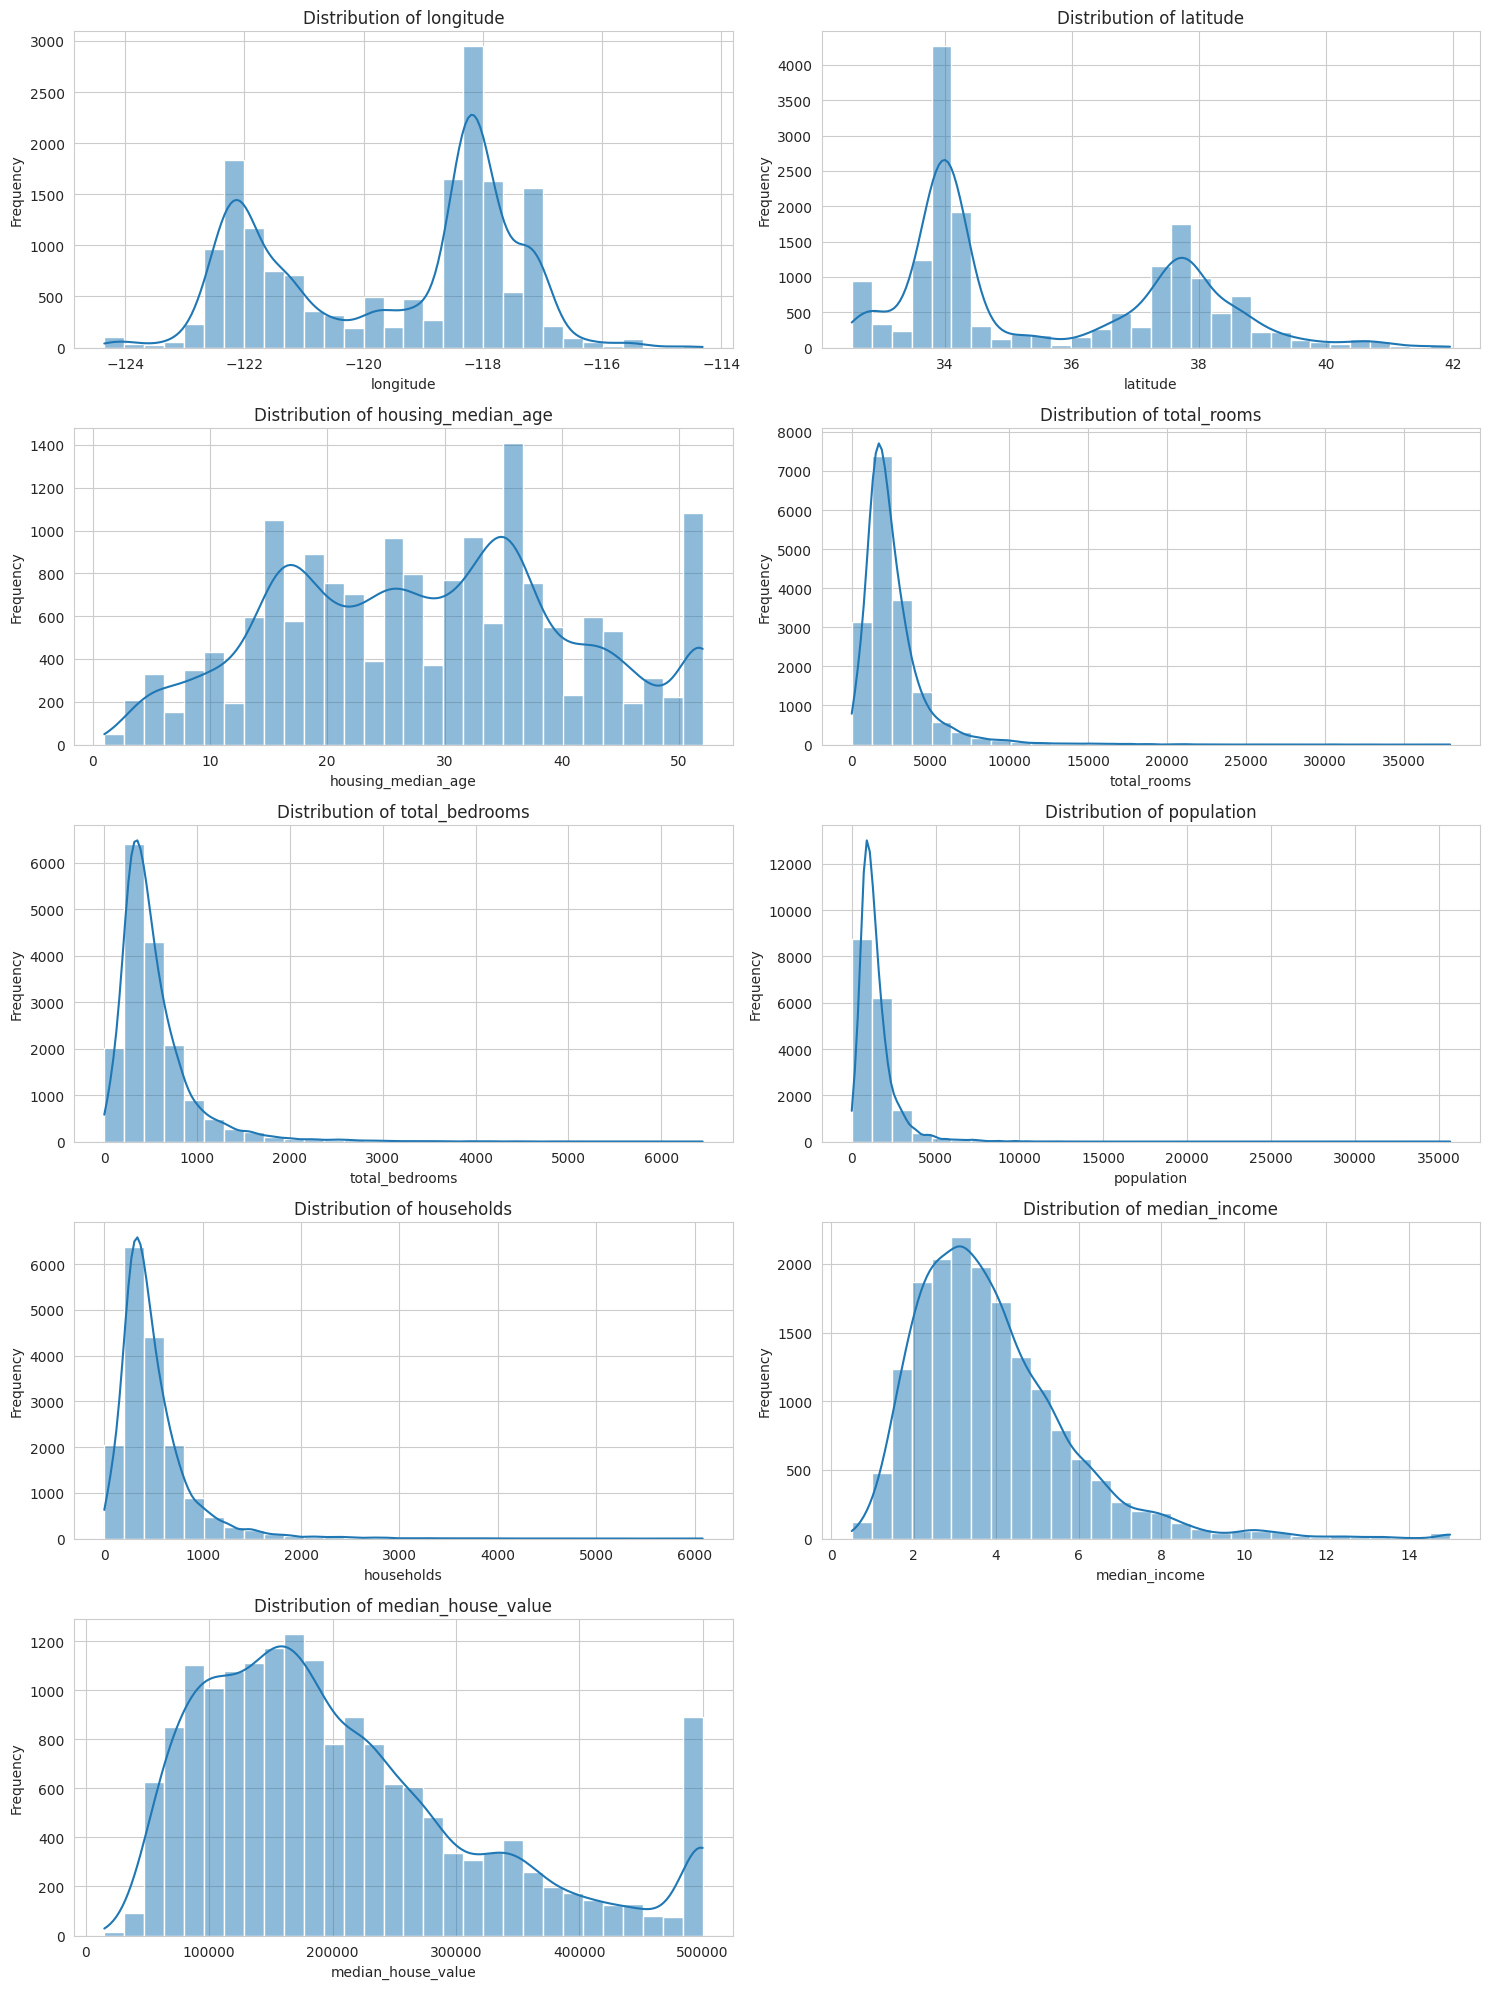

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Get the list of numerical columns
numerical_cols = df_housing.select_dtypes(include=['float64', 'int64']).columns

# Plot histograms for all numerical features
plt.figure(figsize=(15, 20))
for i, col in enumerate(numerical_cols):
    plt.subplot(5, 2, i + 1) # Adjust subplot grid based on number of columns
    sns.histplot(df_housing[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
correlation_matrix = df_housing.corr()

print("Correlation Matrix:")
display(correlation_matrix)

Correlation Matrix:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.925208,-0.114250,0.047010,0.071802,0.101674,0.059628,-0.015485,-0.044982
latitude,-0.925208,1.000000,0.016454,-0.038773,-0.069373,-0.111261,-0.074902,-0.080303,-0.144917
housing_median_age,-0.114250,0.016454,1.000000,-0.360984,-0.320434,-0.295890,-0.302754,-0.115932,0.106758
total_rooms,0.047010,-0.038773,-0.360984,1.000000,0.928403,0.860170,0.919018,0.195383,0.130991
total_bedrooms,0.071802,-0.069373,-0.320434,0.928403,1.000000,0.881169,0.980920,-0.013495,0.045783
population,0.101674,-0.111261,-0.295890,0.860170,0.881169,1.000000,0.909247,-0.000638,-0.027850
households,0.059628,-0.074902,-0.302754,0.919018,0.980920,0.909247,1.000000,0.007644,0.061031
median_income,-0.015485,-0.080303,-0.115932,0.195383,-0.013495,-0.000638,0.007644,1.000000,0.691871
median_house_value,-0.044982,-0.144917,0.106758,0.130991,0.045783,-0.027850,0.061031,0.691871,1.000000


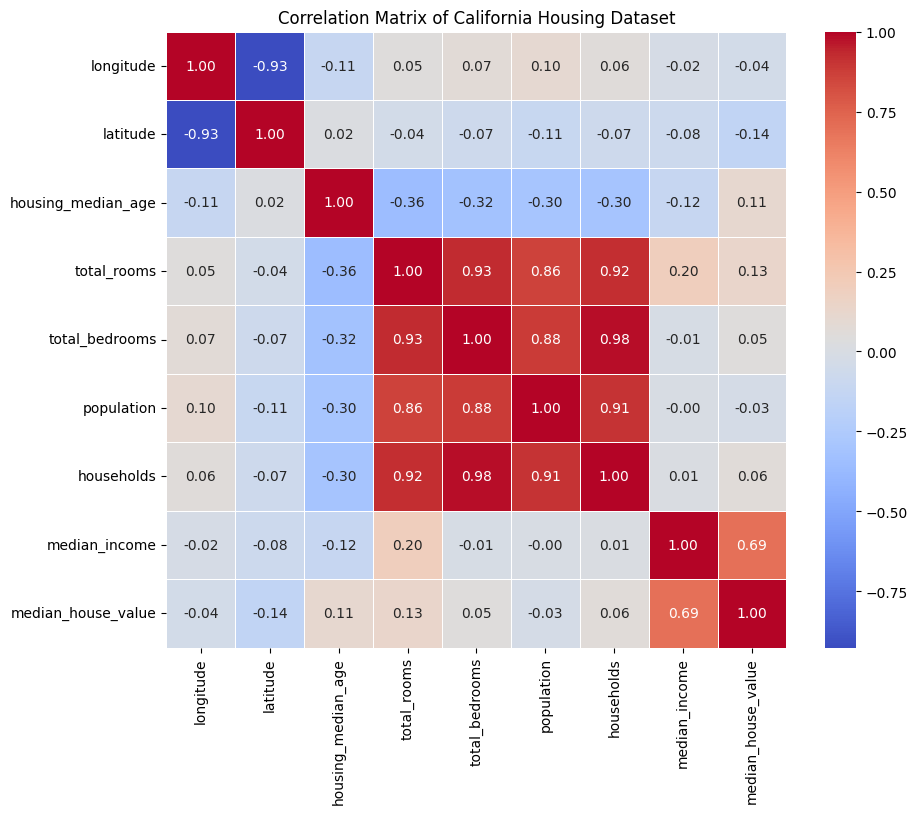

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of California Housing Dataset')
plt.show()

In [ ]:
import pandas as pd

# Create a dictionary to hold the performance metrics
performance_data = {
    'Model': ['Simple Linear Regression', 'Multiple Linear Regression'],
    'Mean Squared Error (MSE)': [slr_mse, mlr_mse],
    'Root Mean Squared Error (RMSE)': [slr_rmse, mlr_rmse],
    'R-squared': [slr_r2, mlr_r2]
}

# Create a DataFrame from the dictionary
performance_df = pd.DataFrame(performance_data)

# Format the numerical columns for better readability
performance_df['Mean Squared Error (MSE)'] = performance_df['Mean Squared Error (MSE)'].map('{:,.2f}'.format)
performance_df['Root Mean Squared Error (RMSE)'] = performance_df['Root Mean Squared Error (RMSE)'].map('{:,.2f}'.format)
performance_df['R-squared'] = performance_df['R-squared'].map('{:.3f}'.format)

print("\nModel Performance Comparison:")
display(performance_df)


Model Performance Comparison:


,Model,Mean Squared Error (MSE),Root Mean Squared Error (RMSE),R-squared
0,Simple Linear Regression,"6,920,028,496.01","83,186.71",0.498
1,Multiple Linear Regression,"4,634,658,406.22","68,078.33",0.664


In [ ]:
print("Descriptive statistics for the California housing training dataset:")
display(df_housing.describe())

Descriptive statistics for the California housing training dataset:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000
mean,-119.562108,35.625225,28.589353,2643.664412,539.410824,1429.573941,501.221941,3.883578,207300.912353
std,2.005166,2.137340,12.586937,2179.947071,421.499452,1147.852959,384.520841,1.908157,115983.764387
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.790000,33.930000,18.000000,1462.000000,297.000000,790.000000,282.000000,2.566375,119400.000000
50%,-118.490000,34.250000,29.000000,2127.000000,434.000000,1167.000000,409.000000,3.544600,180400.000000
75%,-118.000000,37.720000,37.000000,3151.250000,648.250000,1721.000000,605.250000,4.767000,265000.000000
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [ ]:
import pandas as pd

try:
    df_housing = pd.read_csv('/content/sample_data/california_housing_train.csv')
    print("California housing training dataset loaded successfully. Here are the first 5 rows:")
    print(df_housing.head())
    print("\nDataset information:")
    df_housing.info()
except FileNotFoundError:
    print("Error: The 'california_housing_train.csv' file was not found in '/content/sample_data/'. Please ensure the file exists.")
except Exception as e:
    print(f"An error occurred while loading the dataset: {e}")

California housing training dataset loaded successfully. Here are the first 5 rows:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -114.31     34.19                15.0       5612.0          1283.0   
1    -114.47     34.40                19.0       7650.0          1901.0   
2    -114.56     33.69                17.0        720.0           174.0   
3    -114.57     33.64                14.0       1501.0           337.0   
4    -114.57     33.57                20.0       1454.0           326.0   

   population  households  median_income  median_house_value  
0      1015.0       472.0         1.4936             66900.0  
1      1129.0       463.0         1.8200             80100.0  
2       333.0       117.0         1.6509             85700.0  
3       515.0       226.0         3.1917             73400.0  
4       624.0       262.0         1.9250             65500.0  

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 

In [ ]:
import pandas as pd #importing required libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### Data Preparation for Regression Models

First, we need to define our features (X) and the target variable (y). The target variable is `median_house_value`.

For **Simple Linear Regression**, we will choose `median_income` as the independent variable, as it showed a strong correlation with `median_house_value` from our earlier correlation analysis.

For **Multiple Linear Regression**, we will use several relevant features including `median_income`, `total_rooms`, `housing_median_age`, `latitude`, and `longitude`.

In [ ]:
# Define features (X) and target (y)
X = df_housing.drop('median_house_value', axis=1)
y = df_housing['median_house_value']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 13600 samples
Testing set size: 3400 samples


### Simple Linear Regression

We will build a simple linear regression model using `median_income` to predict `median_house_value`.

Simple Linear Regression Performance:
  Mean Squared Error (MSE): 6920028496.01
  Root Mean Squared Error (RMSE): 83186.71
  R-squared: 0.50


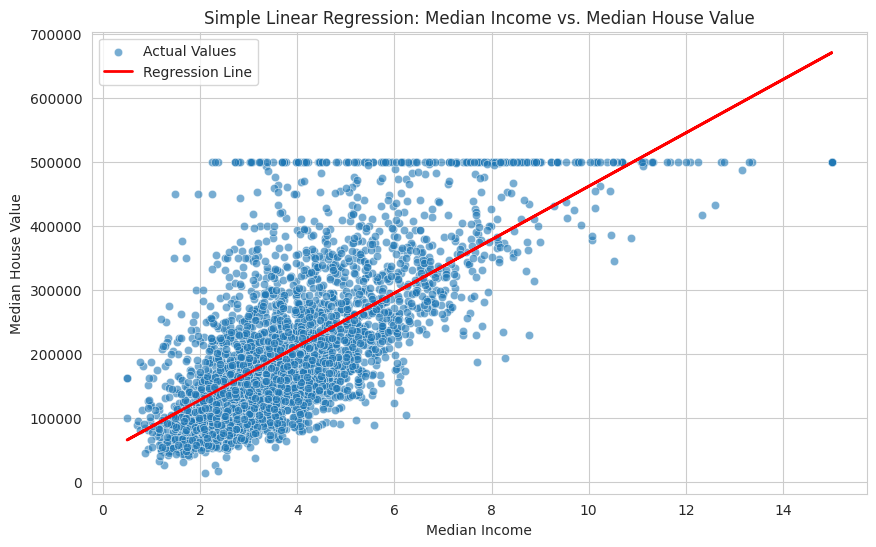

In [ ]:
# Select 'median_income' for Simple Linear Regression
X_slr_train = X_train[['median_income']]
X_slr_test = X_test[['median_income']]

# Initialize and train the Simple Linear Regression model
slr_model = LinearRegression()
slr_model.fit(X_slr_train, y_train)

# Make predictions on the test set
y_slr_pred = slr_model.predict(X_slr_test)

# Evaluate the model
slr_mse = mean_squared_error(y_test, y_slr_pred)
slr_rmse = np.sqrt(slr_mse) # Calculate RMSE by taking the square root of MSE
slr_r2 = r2_score(y_test, y_slr_pred)

print("Simple Linear Regression Performance:")
print(f"  Mean Squared Error (MSE): {slr_mse:.2f}")
print(f"  Root Mean Squared Error (RMSE): {slr_rmse:.2f}")
print(f"  R-squared: {slr_r2:.2f}")

# Visualize the Simple Linear Regression results
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_slr_test['median_income'], y=y_test, alpha=0.6, label='Actual Values')
plt.plot(X_slr_test['median_income'], y_slr_pred, color='red', linewidth=2, label='Regression Line')
plt.title('Simple Linear Regression: Median Income vs. Median House Value')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.legend()
plt.grid(True)
plt.show()

### Multiple Linear Regression

Now, we will build a multiple linear regression model using several features to predict `median_house_value`.

Multiple Linear Regression Performance:
  Mean Squared Error (MSE): 4634658406.22
  Root Mean Squared Error (RMSE): 68078.33
  R-squared: 0.66

MLR Model Coefficients:


,Feature,Coefficient
0,median_income,40194.726347
1,total_rooms,-8.843261
2,housing_median_age,1131.724382
3,latitude,-43106.304441
4,longitude,-43465.247687
5,population,-35.657077
6,households,45.147555
7,total_bedrooms,113.707973


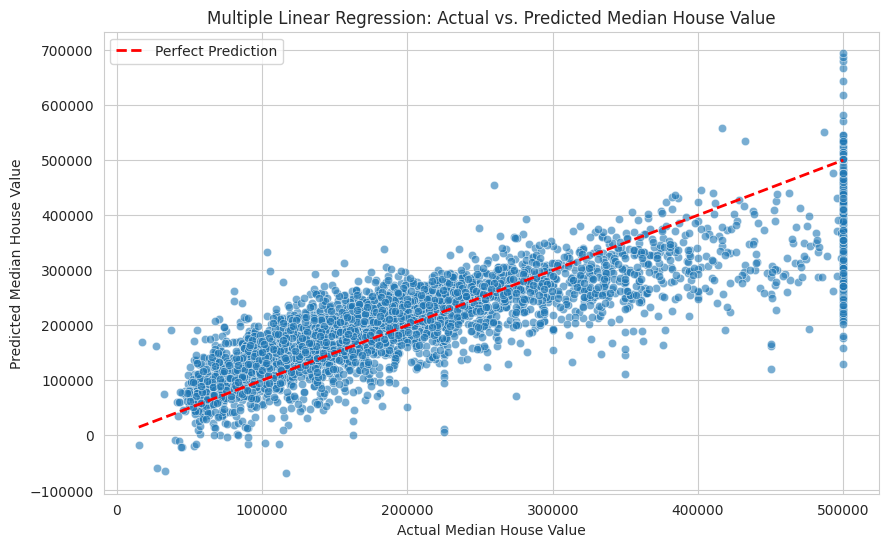

In [ ]:
# Select features for Multiple Linear Regression
# We will use all features except the target variable for simplicity, or we can select specific ones.
# For now, let's use a subset of features that showed some correlation or are generally important.
selected_features = ['median_income', 'total_rooms', 'housing_median_age', 'latitude', 'longitude', 'population', 'households', 'total_bedrooms']

X_mlr_train = X_train[selected_features]
X_mlr_test = X_test[selected_features]

# Initialize and train the Multiple Linear Regression model
mlr_model = LinearRegression()
mlr_model.fit(X_mlr_train, y_train)

# Make predictions on the test set
y_mlr_pred = mlr_model.predict(X_mlr_test)

# Evaluate the model
mlr_mse = mean_squared_error(y_test, y_mlr_pred)
mlr_rmse = np.sqrt(mlr_mse) # Calculate RMSE by taking the square root of MSE
mlr_r2 = r2_score(y_test, y_mlr_pred)

print("Multiple Linear Regression Performance:")
print(f"  Mean Squared Error (MSE): {mlr_mse:.2f}")
print(f"  Root Mean Squared Error (RMSE): {mlr_rmse:.2f}")
print(f"  R-squared: {mlr_r2:.2f}")

# Display coefficients (feature importance for linear models)
print("\nMLR Model Coefficients:")
coefficients_df = pd.DataFrame({'Feature': selected_features, 'Coefficient': mlr_model.coef_})
display(coefficients_df)

# Plotting actual vs. predicted values for Multiple Linear Regression
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_mlr_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Prediction')
plt.title('Multiple Linear Regression: Actual vs. Predicted Median House Value')
plt.xlabel('Actual Median House Value')
plt.ylabel('Predicted Median House Value')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Simple Linear Regression Performance:
  Mean Squared Error (MSE): 6920028496.01
  Root Mean Squared Error (RMSE): 83186.71
  R-squared: 0.50


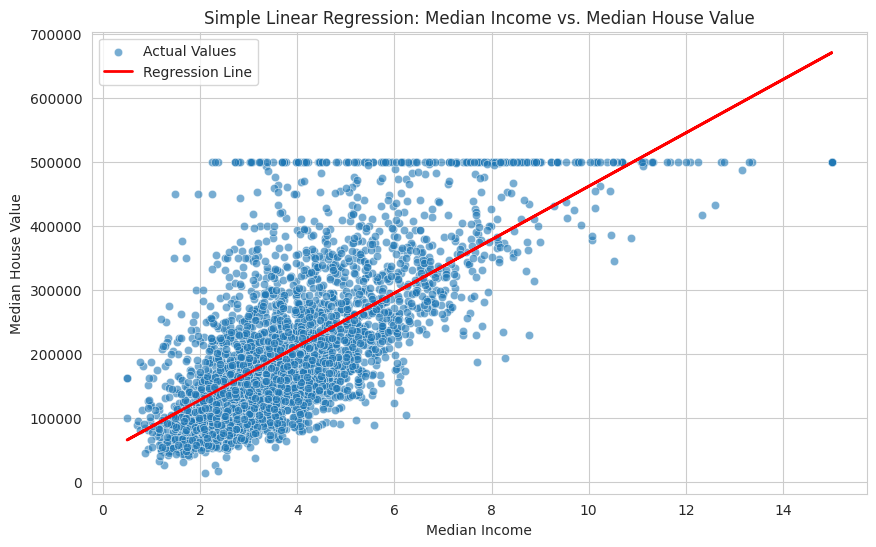

In [ ]:
# Select 'median_income' for Simple Linear Regression
X_slr_train = X_train[['median_income']]
X_slr_test = X_test[['median_income']]

# Initialize and train the Simple Linear Regression model
slr_model = LinearRegression()
slr_model.fit(X_slr_train, y_train)

# Make predictions on the test set
y_slr_pred = slr_model.predict(X_slr_test)

# Evaluate the model
slr_mse = mean_squared_error(y_test, y_slr_pred)
slr_rmse = np.sqrt(slr_mse) # Calculate RMSE by taking the square root of MSE
slr_r2 = r2_score(y_test, y_slr_pred)

print("Simple Linear Regression Performance:")
print(f"  Mean Squared Error (MSE): {slr_mse:.2f}")
print(f"  Root Mean Squared Error (RMSE): {slr_rmse:.2f}")
print(f"  R-squared: {slr_r2:.2f}")

# Visualize the Simple Linear Regression results
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_slr_test['median_income'], y=y_test, alpha=0.6, label='Actual Values')
plt.plot(X_slr_test['median_income'], y_slr_pred, color='red', linewidth=2, label='Regression Line')
plt.title('Simple Linear Regression: Median Income vs. Median House Value')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.legend()
plt.grid(True)
plt.show()

Multiple Linear Regression Performance:
  Mean Squared Error (MSE): 4634658406.22
  Root Mean Squared Error (RMSE): 68078.33
  R-squared: 0.66

MLR Model Coefficients:


,Feature,Coefficient
0,median_income,40194.726347
1,total_rooms,-8.843261
2,housing_median_age,1131.724382
3,latitude,-43106.304441
4,longitude,-43465.247687
5,population,-35.657077
6,households,45.147555
7,total_bedrooms,113.707973


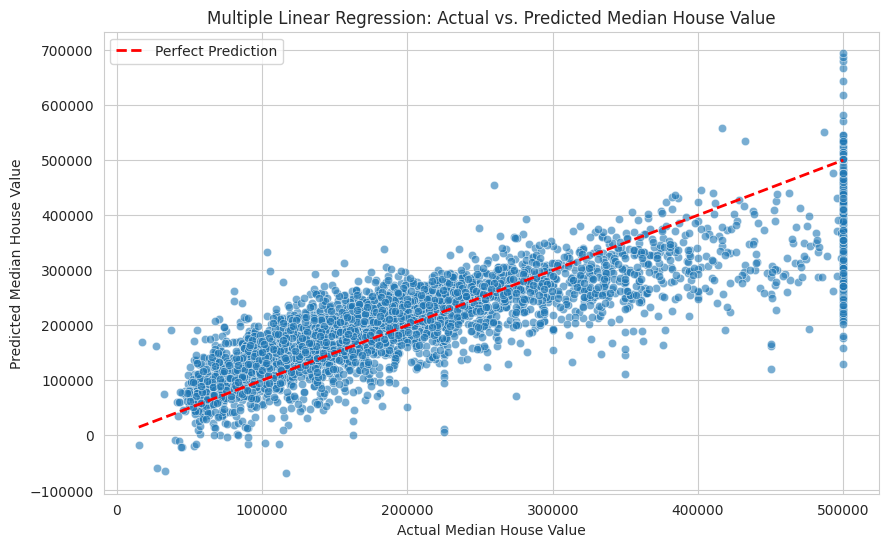

In [ ]:
# Select features for Multiple Linear Regression
# We will use all features except the target variable for simplicity, or we can select specific ones.
# For now, let's use a subset of features that showed some correlation or are generally important.
selected_features = ['median_income', 'total_rooms', 'housing_median_age', 'latitude', 'longitude', 'population', 'households', 'total_bedrooms']

X_mlr_train = X_train[selected_features]
X_mlr_test = X_test[selected_features]

# Initialize and train the Multiple Linear Regression model
mlr_model = LinearRegression()
mlr_model.fit(X_mlr_train, y_train)

# Make predictions on the test set
y_mlr_pred = mlr_model.predict(X_mlr_test)

# Evaluate the model
mlr_mse = mean_squared_error(y_test, y_mlr_pred)
mlr_rmse = np.sqrt(mlr_mse) # Calculate RMSE by taking the square root of MSE
mlr_r2 = r2_score(y_test, y_mlr_pred)

print("Multiple Linear Regression Performance:")
print(f"  Mean Squared Error (MSE): {mlr_mse:.2f}")
print(f"  Root Mean Squared Error (RMSE): {mlr_rmse:.2f}")
print(f"  R-squared: {mlr_r2:.2f}")

# Display coefficients (feature importance for linear models)
print("\nMLR Model Coefficients:")
coefficients_df = pd.DataFrame({'Feature': selected_features, 'Coefficient': mlr_model.coef_})
display(coefficients_df)

# Plotting actual vs. predicted values for Multiple Linear Regression
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_mlr_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Prediction')
plt.title('Multiple Linear Regression: Actual vs. Predicted Median House Value')
plt.xlabel('Actual Median House Value')
plt.ylabel('Predicted Median House Value')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Simple Linear Regression Performance:
  Mean Squared Error (MSE): 6920028496.01
  Root Mean Squared Error (RMSE): 83186.71
  R-squared: 0.50


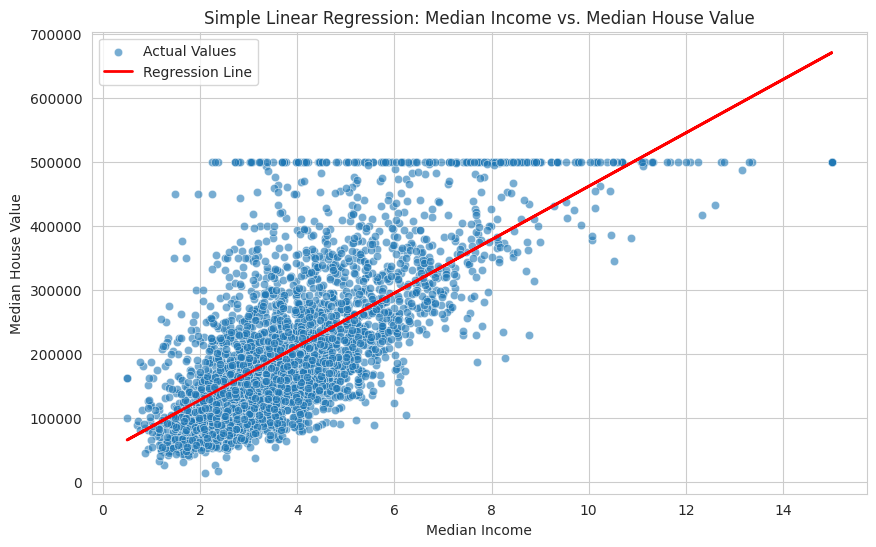

In [ ]:
# Select 'median_income' for Simple Linear Regression
X_slr_train = X_train[['median_income']]
X_slr_test = X_test[['median_income']]

# Initialize and train the Simple Linear Regression model
slr_model = LinearRegression()
slr_model.fit(X_slr_train, y_train)

# Make predictions on the test set
y_slr_pred = slr_model.predict(X_slr_test)

# Evaluate the model
slr_mse = mean_squared_error(y_test, y_slr_pred)
slr_rmse = np.sqrt(slr_mse) # Calculate RMSE by taking the square root of MSE
slr_r2 = r2_score(y_test, y_slr_pred)

print("Simple Linear Regression Performance:")
print(f"  Mean Squared Error (MSE): {slr_mse:.2f}")
print(f"  Root Mean Squared Error (RMSE): {slr_rmse:.2f}")
print(f"  R-squared: {slr_r2:.2f}")

# Visualize the Simple Linear Regression results
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_slr_test['median_income'], y=y_test, alpha=0.6, label='Actual Values')
plt.plot(X_slr_test['median_income'], y_slr_pred, color='red', linewidth=2, label='Regression Line')
plt.title('Simple Linear Regression: Median Income vs. Median House Value')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.legend()
plt.grid(True)
plt.show()

Multiple Linear Regression Performance:
  Mean Squared Error (MSE): 4634658406.22
  Root Mean Squared Error (RMSE): 68078.33
  R-squared: 0.66

MLR Model Coefficients:


,Feature,Coefficient
0,median_income,40194.726347
1,total_rooms,-8.843261
2,housing_median_age,1131.724382
3,latitude,-43106.304441
4,longitude,-43465.247687
5,population,-35.657077
6,households,45.147555
7,total_bedrooms,113.707973


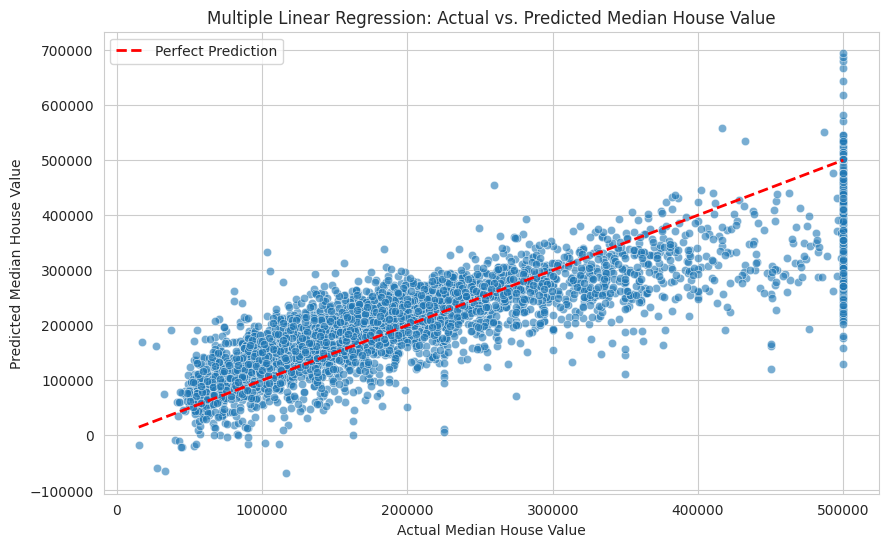

In [ ]:
# Select features for Multiple Linear Regression
# We will use all features except the target variable for simplicity, or we can select specific ones.
# For now, let's use a subset of features that showed some correlation or are generally important.
selected_features = ['median_income', 'total_rooms', 'housing_median_age', 'latitude', 'longitude', 'population', 'households', 'total_bedrooms']

X_mlr_train = X_train[selected_features]
X_mlr_test = X_test[selected_features]

# Initialize and train the Multiple Linear Regression model
mlr_model = LinearRegression()
mlr_model.fit(X_mlr_train, y_train)

# Make predictions on the test set
y_mlr_pred = mlr_model.predict(X_mlr_test)

# Evaluate the model
mlr_mse = mean_squared_error(y_test, y_mlr_pred)
mlr_rmse = np.sqrt(mlr_mse) # Calculate RMSE by taking the square root of MSE
mlr_r2 = r2_score(y_test, y_mlr_pred)

print("Multiple Linear Regression Performance:")
print(f"  Mean Squared Error (MSE): {mlr_mse:.2f}")
print(f"  Root Mean Squared Error (RMSE): {mlr_rmse:.2f}")
print(f"  R-squared: {mlr_r2:.2f}")

# Display coefficients (feature importance for linear models)
print("\nMLR Model Coefficients:")
coefficients_df = pd.DataFrame({'Feature': selected_features, 'Coefficient': mlr_model.coef_})
display(coefficients_df)

# Plotting actual vs. predicted values for Multiple Linear Regression
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_mlr_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Prediction')
plt.title('Multiple Linear Regression: Actual vs. Predicted Median House Value')
plt.xlabel('Actual Median House Value')
plt.ylabel('Predicted Median House Value')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd

# Create a dictionary to hold the performance metrics
performance_data = {
    'Model': ['Simple Linear Regression', 'Multiple Linear Regression'],
    'Mean Squared Error (MSE)': [slr_mse, mlr_mse],
    'Root Mean Squared Error (RMSE)': [slr_rmse, mlr_rmse],
    'R-squared': [slr_r2, mlr_r2]
}

# Create a DataFrame from the dictionary
performance_df = pd.DataFrame(performance_data)

# Format the numerical columns for better readability
performance_df['Mean Squared Error (MSE)'] = performance_df['Mean Squared Error (MSE)'].map('{:,.2f}'.format)
performance_df['Root Mean Squared Error (RMSE)'] = performance_df['Root Mean Squared Error (RMSE)'].map('{:,.2f}'.format)
performance_df['R-squared'] = performance_df['R-squared'].map('{:.3f}'.format)

print("\nModel Performance Comparison:")
display(performance_df)


Model Performance Comparison:


,Model,Mean Squared Error (MSE),Root Mean Squared Error (RMSE),R-squared
0,Simple Linear Regression,"6,920,028,496.01","83,186.71",0.498
1,Multiple Linear Regression,"4,634,658,406.22","68,078.33",0.664
